<a href="https://colab.research.google.com/github/api-sage/diaml_projects/blob/main/Project2/pafolabi_DIAML_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data, Inference, and Applied Machine Learning**: Project Assignment II

In [74]:
#Imports all neccessary Python libraries
import numpy as np
import pandas as pd
import math as math
import matplotlib.pyplot as plt
import seaborn as sns

##Question 1
**Data source**: [World Bank Indicators](https://data.worldbank.org/indicator)

###a. Before looking at the data, state what kind of relationship you expect.
Before looking at the data of **GDP per capita (current
US$)** and **Prevalence of underweight, weight for age
(% of children under 5)**, I expect to see the following relationship:
1. As the world GDP increases (the GDP of countries), I expect that the percentage of underweight children decreases, yielding an inverse relationship between world GDP and percentage of underweight children.
2. The cumulative world GDP over several years.
3. The amount, either in percentage or in realised value, various countries contributed to the world GDP growth in an accounting year.
4. The percentage of underweight children in the world over a good number of years.
---
###b. Clean the data and say what you removed and why. Report how many years of observations and how many distinct countries you are left with.

In [80]:
# Data ingestion and cleaning

# 1. World GDP Data Ingestion
world_gdp_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_gdp/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_328572.csv',
                           skiprows=4)
world_gdp_metadata_country_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_gdp/Metadata_Country_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_328572.csv')
world_gdp_indicator_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_gdp/Metadata_Indicator_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_328572.csv')


# 2. World Percentage of Underage Children Data Ingestion
world_pcnt_underwgth_chld_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_percent_underweight/API_SH.STA.MALN.ZS_DS2_en_csv_v2_334227.csv',
    skiprows=4)
world_pcnt_underwgth_chld_metadata_country_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_percent_underweight/Metadata_Country_API_SH.STA.MALN.ZS_DS2_en_csv_v2_334227.csv')
world_pcnt_underwgth_chld_metadata_indicator_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_percent_underweight/Metadata_Indicator_API_SH.STA.MALN.ZS_DS2_en_csv_v2_334227.csv')

# 3. Exploration of DFs
#world_gdp_df.head()
#world_gdp_metadata_country_df.head()
#world_gdp_indicator_df.head()

#world_pcnt_underwgth_chld_df.count()
#world_pcnt_underwgth_chld_metadata_country_df.tail()
#world_pcnt_underwgth_chld_metadata_indicator_df.head()

# 4. Data cleaning operations
region_notna = world_gdp_metadata_country_df['Region'].notna()
country_codes = world_gdp_metadata_country_df[region_notna]['Country Code']
clean_world_gdp_df = world_gdp_df[world_gdp_df['Country Code'].isin(country_codes)]
clean_world_underweight_df = world_pcnt_underwgth_chld_df[world_pcnt_underwgth_chld_df['Country Code'].isin(country_codes)]

world_gdp_long_df = clean_world_gdp_df.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[str(year) for year in range(1960, 2026) if str(year) in clean_world_gdp_df.columns],
    var_name='Year',
    value_name='GDP_per_capita'
)

world_pcnt_underwight_long_df = clean_world_underweight_df.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[str(year) for year in range(1960, 2026) if str(year) in clean_world_underweight_df.columns],
    var_name='Year',
    value_name='Percentage_Underweight'
)

merged_df = pd.merge(
    world_gdp_long_df,
    world_pcnt_underwight_long_df,
    on=['Country Code', 'Country Name','Year'],
    how='inner'
)

final_df = merged_df.dropna(subset=['GDP_per_capita', 'Percentage_Underweight'])
final_df['Year'] = final_df['Year'].astype(int)


/tmp/ipykernel_2468/787208523.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['Year'] = final_df['Year'].astype(int)


### Explanation of Data Cleaning

1.  **Filtering by Region**: Initially, both the World GDP and Underweight Children datasets contained aggregate entities (e.g., 'World', 'European Union') which are not individual countries. These were removed by filtering for 'Country Code' values that corresponded to entries with a non-null 'Region' in the `world_gdp_metadata_country_df`. This ensures that only actual country data is considered.
2.  **Melting DataFrames**: The raw data was in a wide format, with each year as a separate column. I transformed both datasets into a 'long' format using `melt()`. This reshaped the data so that each row represents a unique combination of country and year, with separate columns for 'Year', 'Country Name', 'Country Code', and the respective indicator values ('GDP_per_capita' or 'Percentage_Underweight'). This is essential for easier merging and time-series analysis.
3.  **Merging DataFrames**: The GDP per capita and Percentage Underweight data were merged into a single DataFrame (`merged_df`) using 'Country Code', 'Country Name', and 'Year' as common keys. An 'inner' merge was used, meaning only rows that have matching values in all key columns in both DataFrames were kept. This ensures we only have data points where both indicators are available for a given country and year.
4.  **Handling Missing Values**: Finally, rows where either 'GDP_per_capita' or 'Percentage_Underweight' had missing values (NaN) were dropped using `dropna()`. This step ensures that our analysis only uses complete data points, preventing skewing from incomplete observations.
5.  **Data Type Conversion**: The 'Year' column was converted to an integer type for consistency and easier numerical operations.


In [76]:
num_years = final_df['Year'].nunique()
num_countries = final_df['Country Name'].nunique()

print(f"Number of years of observations: {num_years}")
print(f"Number of distinct countries: {num_countries}")

Number of years of observations: 42
Number of distinct countries: 161


### c. Make a scatter plot of malnutrition prevalence against GDP per capita, using all available years and countries. What kind of relationship do you see, and how does it compare with your hypothesis? Then redraw the same plot with GDP per capita on a logarithmic axis, and say which of the two you would publish.

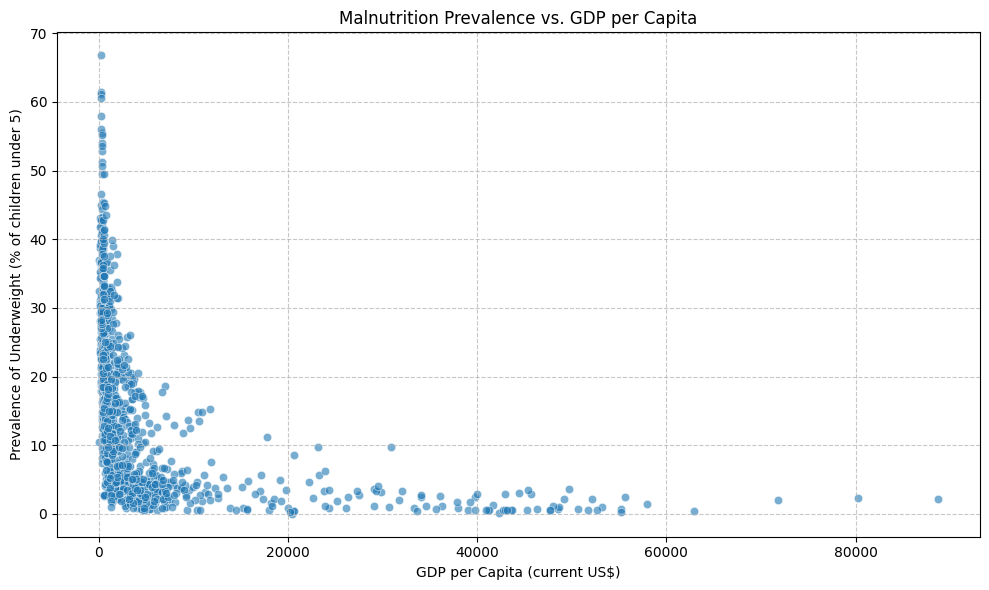

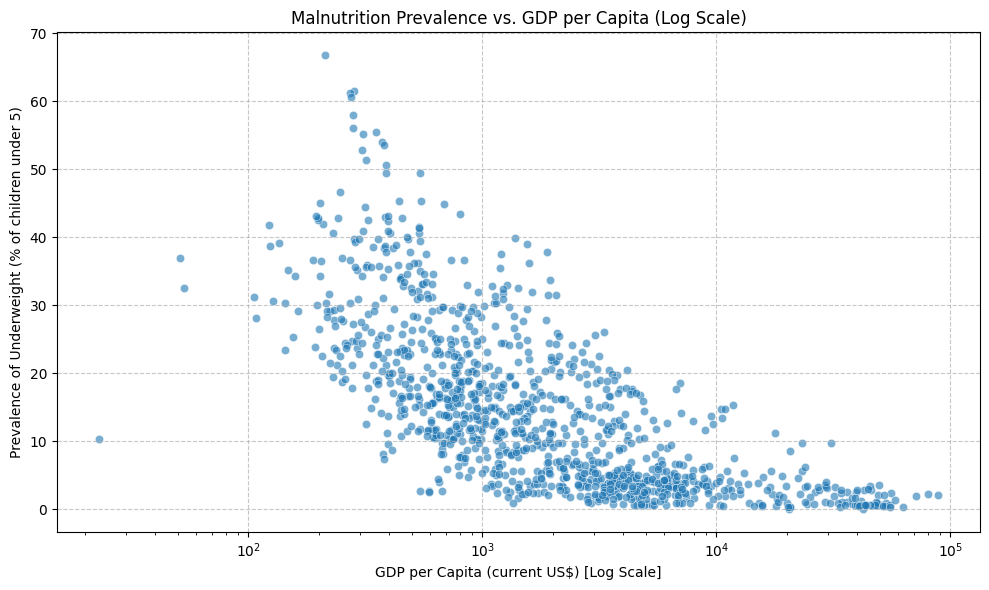

In [77]:
# Scatter plot of malnutrition prevalence against GDP per capita
fig1 = plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_df, x='GDP_per_capita', y='Percentage_Underweight', alpha=0.6)
plt.title('Malnutrition Prevalence vs. GDP per Capita')
plt.xlabel('GDP per Capita (current US$)')
plt.ylabel('Prevalence of Underweight (% of children under 5)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Scatter plot with GDP per capita on a logarithmic axis
fig2 = plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_df, x='GDP_per_capita', y='Percentage_Underweight', alpha=0.6)
plt.xscale('log')
plt.title('Malnutrition Prevalence vs. GDP per Capita (Log Scale)')
plt.xlabel('GDP per Capita (current US$) [Log Scale]')
plt.ylabel('Prevalence of Underweight (% of children under 5)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Analysis of Plots (Question 1.c)

**Relationship Observed (Linear Scale)**:

In the first scatter plot (linear scale), we can observe a general trend where as GDP per capita increases, the prevalence of underweight children tends to decrease. This aligns with the initial hypothesis of an inverse relationship. However, the data points are heavily clustered towards the lower end of the GDP per capita scale, making it difficult to discern patterns among countries with lower GDP and to fully appreciate the relationship across the entire range.

**Relationship Observed (Logarithmic Scale)**:

The second scatter plot, with GDP per capita on a logarithmic axis, provides a much clearer view of the relationship. The logarithmic scale compresses the higher GDP values and expands the lower GDP values, spreading out the clustered points and revealing more detail. In this plot, the inverse relationship is more evident and appears more consistent across different income levels. The distribution of data points is more uniform, allowing for better identification of trends and outliers.

**Which plot to publish?**:

I would publish the **scatter plot with GDP per capita on a logarithmic axis**. This is because:

*   **Better Visualization of Skewed Data**: Economic data like GDP per capita often has a heavily skewed distribution, with a few high-income countries and many low-to-middle-income countries. A logarithmic scale effectively handles this skewness, making the distribution of data points more interpretable.
*   **Clearer Trend Identification**: The inverse relationship between GDP per capita and malnutrition prevalence is much more clearly and evenly depicted across the range of GDP values on a logarithmic scale. It allows us to observe nuances in the relationship that are obscured on a linear scale.
*   **Enhanced Detail for Lower GDP Countries**: The logarithmic scale provides more visual emphasis on the differences among lower GDP countries, which are often the most relevant for studying malnutrition.


### d. Make a scatter plot coloured by geographical region and another coloured by income level. Which of the two plots is more informative?

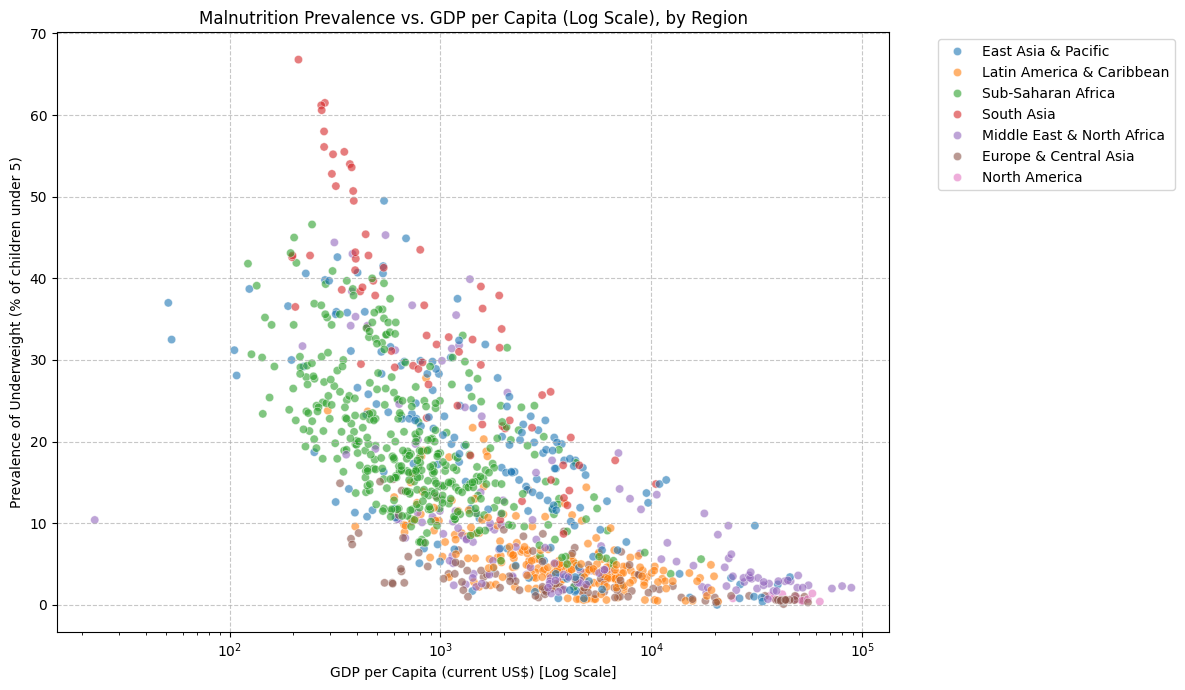

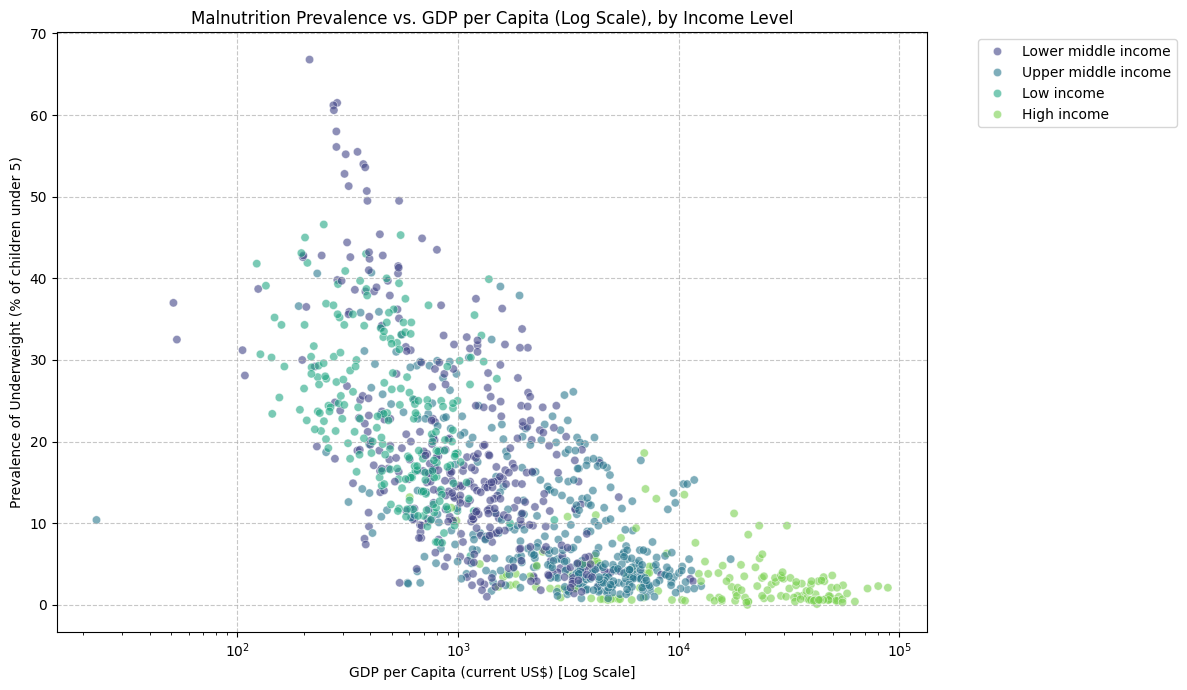

In [78]:
metadata_df = world_gdp_metadata_country_df[['Country Code', 'Region', 'IncomeGroup']].copy()
final_df_with_metadata = pd.merge(final_df, metadata_df, on='Country Code', how='left')

# Scatter plot colored by Geographical Region
fig3 = plt.figure(figsize=(12, 7))
sns.scatterplot(data=final_df_with_metadata, x='GDP_per_capita', y='Percentage_Underweight', hue='Region', alpha=0.6, palette='tab10')
plt.xscale('log')
plt.title('Malnutrition Prevalence vs. GDP per Capita (Log Scale), by Region')
plt.xlabel('GDP per Capita (current US$) [Log Scale]')
plt.ylabel('Prevalence of Underweight (% of children under 5)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Scatter plot colored by Income Level
fig4 = plt.figure(figsize=(12, 7))
sns.scatterplot(data=final_df_with_metadata, x='GDP_per_capita', y='Percentage_Underweight', hue='IncomeGroup', alpha=0.6, palette='viridis')
plt.xscale('log')
plt.title('Malnutrition Prevalence vs. GDP per Capita (Log Scale), by Income Level')
plt.xlabel('GDP per Capita (current US$) [Log Scale]')
plt.ylabel('Prevalence of Underweight (% of children under 5)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Analysis of Plots (Question 1.d)

**Which plot is more informative?**

Both plots offer valuable insights, but the **scatter plot colored by Income Level is generally more informative** for understanding the relationship between GDP per capita and malnutrition prevalence.

Here's why:

*   **Direct Correlation with GDP**: Income Group is directly defined by GDP per capita. Therefore, coloring by income level inherently reinforces and clarifies the underlying trend. We can clearly see how countries transition from 'Low income' (typically higher malnutrition, lower GDP) through 'Lower middle income', 'Upper middle income', to 'High income' (typically lower malnutrition, higher GDP), creating a more structured and coherent visual progression.

*   **Clearer Segregation of Trends**: The income level categories tend to group countries with similar economic development and, consequently, similar levels of malnutrition and GDP. This provides a more distinct and understandable segmentation of the data, allowing us to easily identify clusters and patterns within each income group.

*   **Actionable Insights**: From a policy perspective, understanding the relationship within specific income groups can be more actionable. Interventions for malnutrition might differ significantly between a 'Low income' country and a 'High income' country, even if both are in the same geographical region.

**Comparison with Geographical Region Plot**:

The plot colored by geographical region is also useful, as it shows regional disparities. For example, countries in 'Sub-Saharan Africa' might consistently appear at the lower end of the GDP scale with higher malnutrition. However, geographical regions are more diverse in terms of economic development. A single region might contain countries with vastly different GDPs and malnutrition rates, leading to more overlapping and less clear-cut distinctions between the colored groups compared to income levels. While it highlights regional clusters, it doesn't explain the *why* of the GDP-malnutrition relationship as effectively as income groups do.

In conclusion, while both plots offer different perspectives, the **Income Level plot provides a more direct and interpretable visual explanation of the relationship between a country's economic standing (proxied by GDP) and its child malnutrition rates.**

### e. Plot the number of observations per year. What do you observe about reporting frequency?

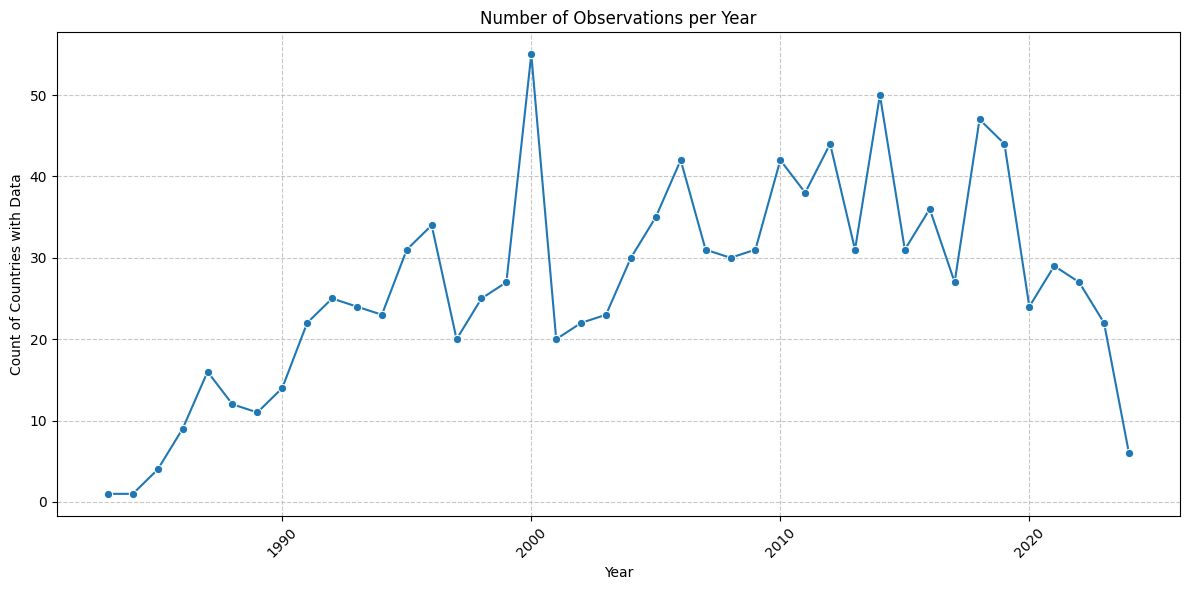

In [79]:
# Plot the number of observations per year
observations_per_year = final_df.groupby('Year').size().reset_index(name='Number of Observations')

fig5 = plt.figure(figsize=(12, 6))
sns.lineplot(data=observations_per_year, x='Year', y='Number of Observations', marker='o')
plt.title('Number of Observations per Year')
plt.xlabel('Year')
plt.ylabel('Count of Countries with Data')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Analysis of Reporting Frequency (Question 1.e)

**Observations about reporting frequency:**

The plot showing the 'Number of Observations per Year' reveals several insights into the reporting frequency of both GDP per capita and the prevalence of underweight children:

*   **Sparse Data in Earlier Years**: There are very few observations in the earlier years (e.g., prior to 1980s). This suggests that data collection for one or both indicators was either not comprehensive or not systematically recorded for many countries during those periods.

*   **Increasing Trend over Time**: From the late 1980s or early 1990s, there is a clear upward trend in the number of observations per year. This indicates an improvement in data collection and reporting over time, with more countries providing data for both indicators.

*   **Fluctuations and Gaps**: Despite the general increasing trend, there are noticeable fluctuations and gaps in reporting. Some years have fewer observations than preceding or succeeding years, suggesting that data might not be collected annually for all countries or that reporting can be irregular.

*   **Peak Reporting**: The number of observations appears to peak around the mid-2000s to early 2010s, after which there might be a slight decline or stabilization. This could indicate periods of focused data collection efforts or changes in reporting methodologies.

*   **Most Recent Years Lack Data**: There's a sharp drop-off in observations for the most recent years (e.g., after 2015-2020). This is expected as data collection and compilation often take time, and the latest figures might not yet be available in the datasets. The datasets might also contain 'future' years with no actual data yet, contributing to the drop-off.

In summary, the reporting frequency for these indicators has improved significantly over the decades, though it remains somewhat inconsistent annually, and there is a natural lag in the availability of the most recent data.